In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.impute import SimpleImputer

from sklearn.model_selection import GridSearchCV, cross_val_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("diabetes (1).csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#Histograms

Visualize the distribution of numerical features.

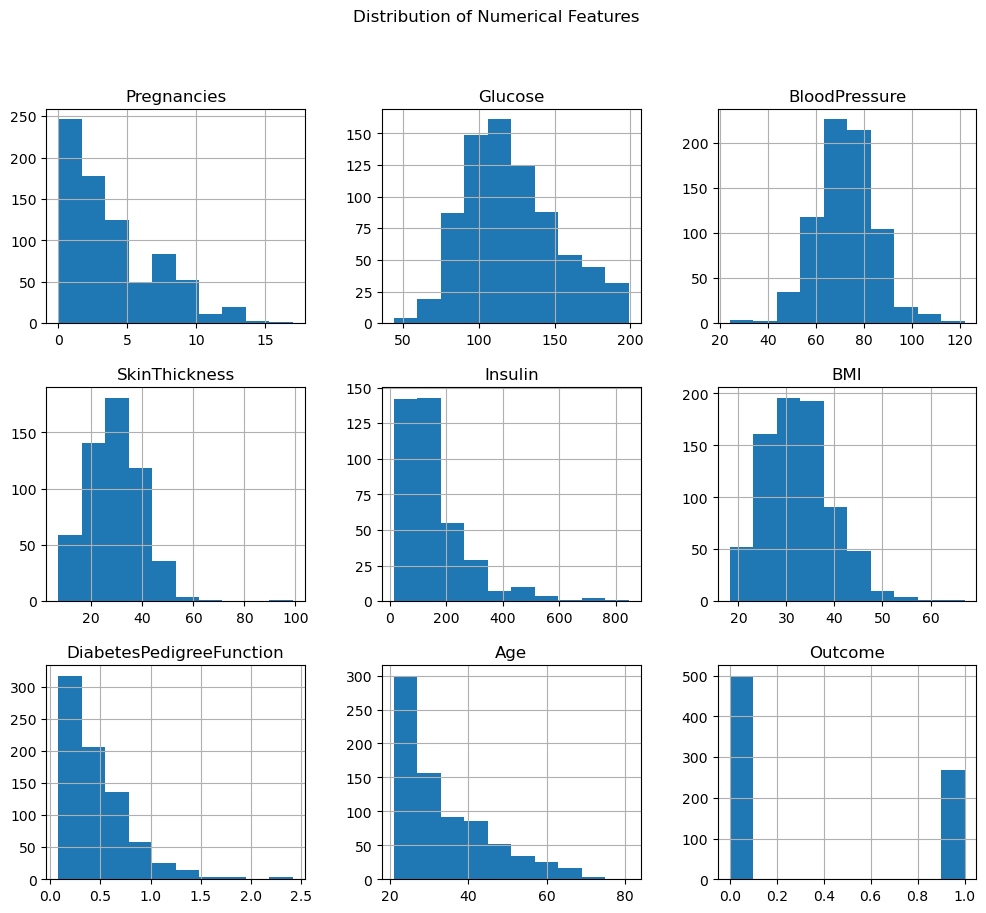

In [7]:
df.hist(figsize=(12,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

#Box Plots

Box plots help identify outliers in numerical features.

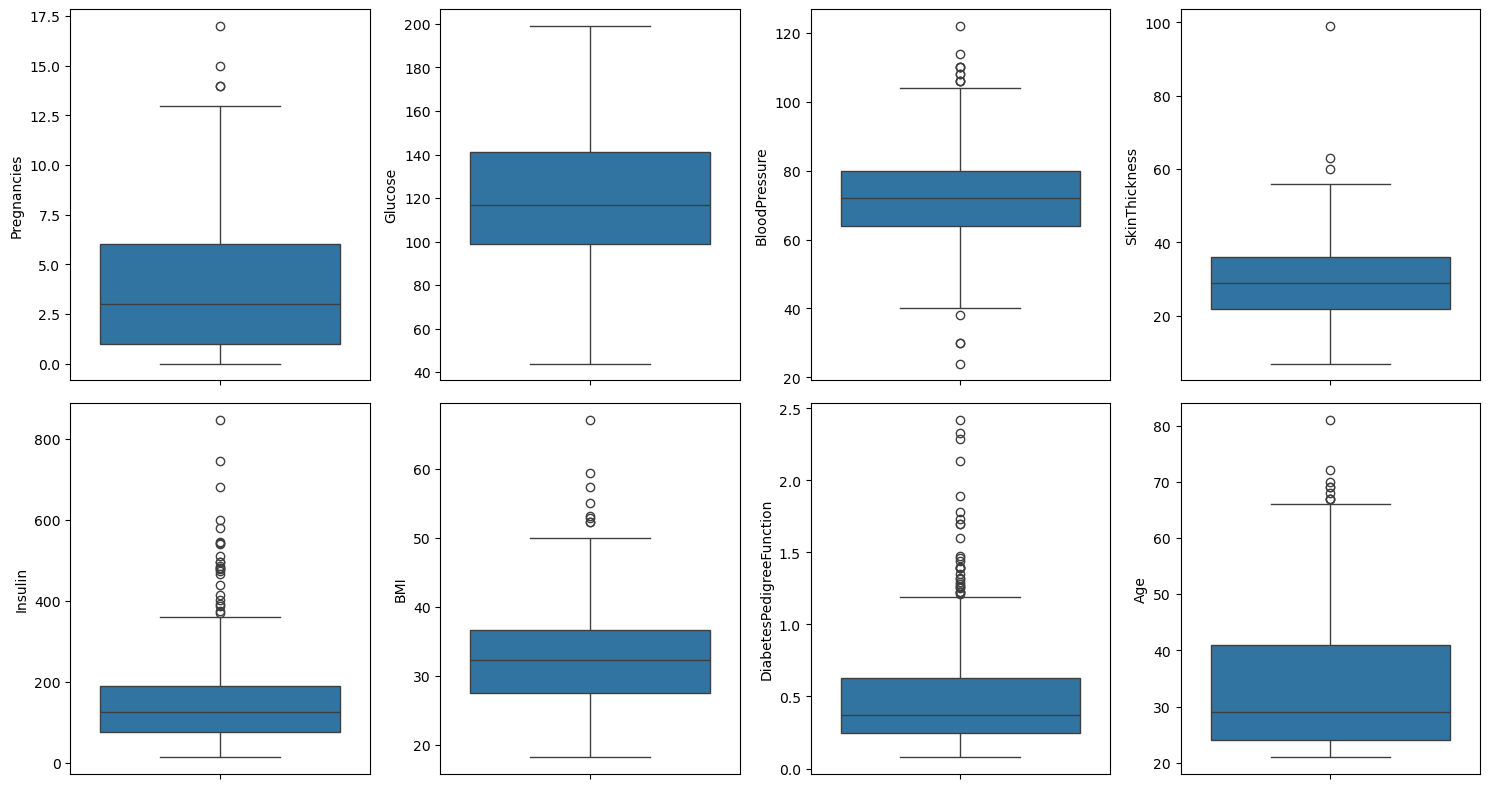

In [9]:
plt.figure(figsize=(15,8))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

#Scatter Plot

Visualize the relationship between Glucose and BMI.

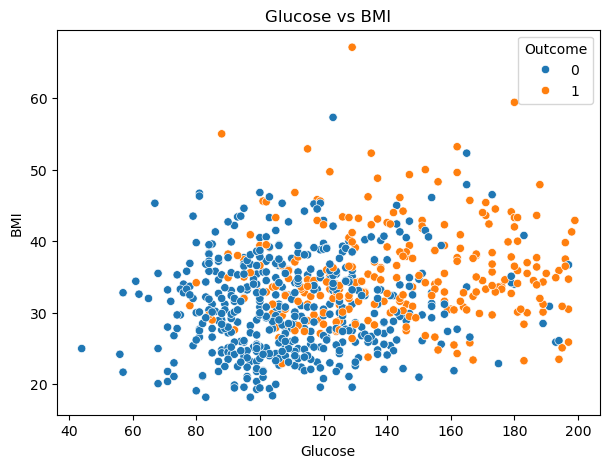

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='Glucose',
                y='BMI',
                hue='Outcome',
                data=df)

plt.title("Glucose vs BMI")
plt.show()

#Bar Plot

Visualize the distribution of diabetic and non-diabetic patients.

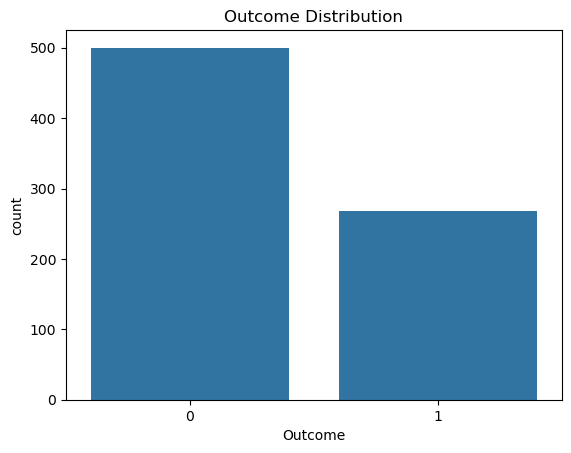

In [11]:
sns.countplot(x='Outcome',data=df)

plt.title("Outcome Distribution")
plt.show()

#Correlation Matrix

Visualize relationships among numerical variables.

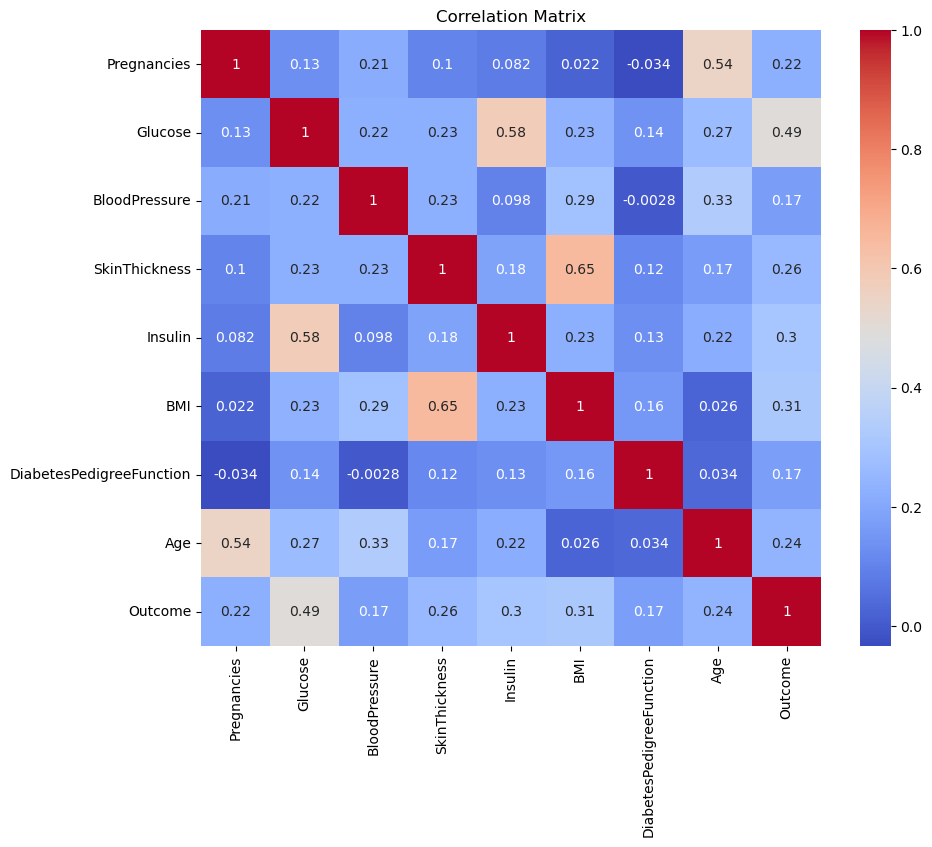

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

#Feature Selection

Separate the independent and dependent variables.

In [14]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

#Train-Test Split

Split the dataset into training and testing datasets.

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
#Build XGBoost Model

In [17]:
xgb=XGBClassifier(random_state=42)

xgb.fit(X_train,y_train)

y_pred_xgb=xgb.predict(X_test)

In [18]:
# Evaluate XGBoost Model

In [19]:
print("Accuracy :",accuracy_score(y_test,y_pred_xgb))
print("Precision :",precision_score(y_test,y_pred_xgb))
print("Recall :",recall_score(y_test,y_pred_xgb))
print("F1 Score :",f1_score(y_test,y_pred_xgb))

print(classification_report(y_test,y_pred_xgb))

Accuracy : 0.7337662337662337
Precision : 0.6060606060606061
Recall : 0.7272727272727273
F1 Score : 0.6611570247933884
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        99
           1       0.61      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [20]:
# Build LightGBM Model

In [21]:
lgb=LGBMClassifier(random_state=42)

lgb.fit(X_train,y_train)

y_pred_lgb=lgb.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [22]:
print("Accuracy :",accuracy_score(y_test,y_pred_lgb))
print("Precision :",precision_score(y_test,y_pred_lgb))
print("Recall :",recall_score(y_test,y_pred_lgb))
print("F1 Score :",f1_score(y_test,y_pred_lgb))

print(classification_report(y_test,y_pred_lgb))

Accuracy : 0.7207792207792207
Precision : 0.6
Recall : 0.6545454545454545
F1 Score : 0.6260869565217392
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        99
           1       0.60      0.65      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



#Cross Validation

Evaluate the stability of both models using 5-fold cross-validation.

In [24]:
cv_xgb=cross_val_score(xgb,X,y,cv=5,scoring="accuracy")
cv_lgb=cross_val_score(lgb,X,y,cv=5,scoring="accuracy")

print("XGBoost Mean Accuracy :",cv_xgb.mean())
print("LightGBM Mean Accuracy :",cv_lgb.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

#Hyperparameter Tuning

Optimize the models using GridSearchCV.

In [25]:
param_grid={
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5],
    'n_estimators':[100,200]
}

grid_xgb=GridSearchCV(XGBClassifier(random_state=42),
                      param_grid,
                      cv=5)

grid_xgb.fit(X_train,y_train)

print(grid_xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [26]:
param_grid={
    'learning_rate':[0.01,0.1],
    'num_leaves':[20,31,40],
    'n_estimators':[100,200]
}

grid_lgb=GridSearchCV(LGBMClassifier(random_state=42),
                      param_grid,
                      cv=5)

grid_lgb.fit(X_train,y_train)

print(grid_lgb.best_params_)

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

#Comparative Analysis

Compare the performance metrics of both models.

In [27]:
results=pd.DataFrame({

'Model':['XGBoost','LightGBM'],

'Accuracy':[accuracy_score(y_test,y_pred_xgb),
            accuracy_score(y_test,y_pred_lgb)],

'Precision':[precision_score(y_test,y_pred_xgb),
             precision_score(y_test,y_pred_lgb)],

'Recall':[recall_score(y_test,y_pred_xgb),
          recall_score(y_test,y_pred_lgb)],

'F1 Score':[f1_score(y_test,y_pred_xgb),
            f1_score(y_test,y_pred_lgb)]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.733766,0.606061,0.727273,0.661157
1,LightGBM,0.720779,0.600000,0.654545,0.626087


#Accuracy Comparison

Visualize the accuracy of LightGBM and XGBoost.

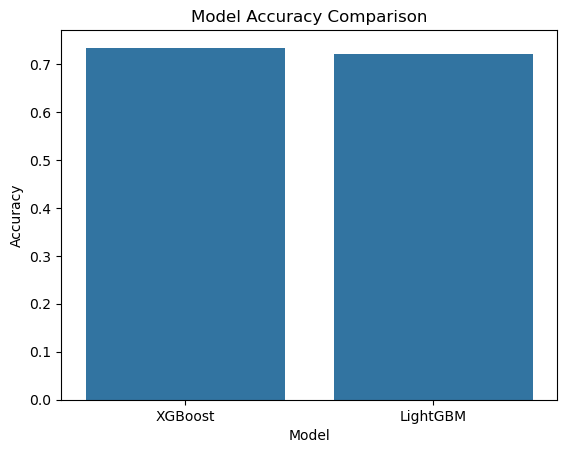

In [28]:
sns.barplot(x="Model",
            y="Accuracy",
            data=results)

plt.title("Model Accuracy Comparison")

plt.show()

#ROC Curve Comparison

Compare the ROC curves of XGBoost and LightGBM models.

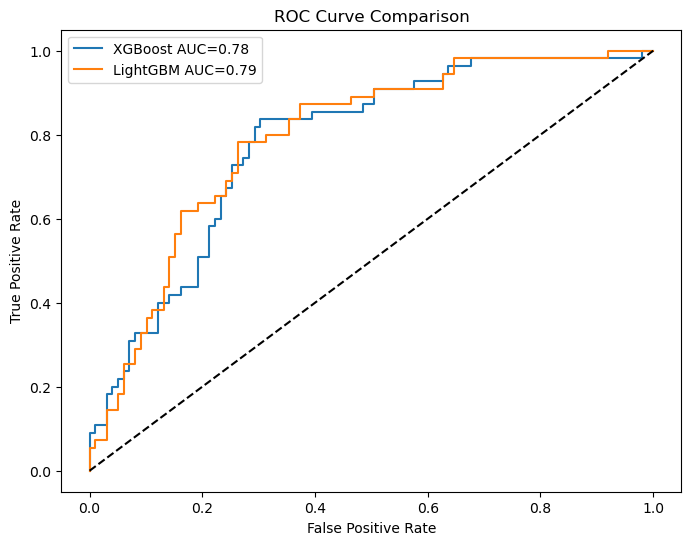

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score,auc
import matplotlib.pyplot as plt
xgb_prob=xgb.predict_proba(X_test)[:,1]
lgb_prob=lgb.predict_proba(X_test)[:,1]

fpr1,tpr1,_=roc_curve(y_test,xgb_prob)
fpr2,tpr2,_=roc_curve(y_test,lgb_prob)

auc1=auc(fpr1,tpr1)
auc2=auc(fpr2,tpr2)

plt.figure(figsize=(8,6))

plt.plot(fpr1,tpr1,label=f"XGBoost AUC={auc1:.2f}")
plt.plot(fpr2,tpr2,label=f"LightGBM AUC={auc2:.2f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#Conclusion

Both LightGBM and XGBoost are powerful gradient boosting algorithms for classification tasks.

- XGBoost provides excellent predictive performance and robustness.
- LightGBM offers faster training and lower memory usage, making it suitable for large datasets.
- Cross-validation and hyperparameter tuning improve the overall performance of both models.
- Based on evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC, the better-performing model can be selected for diabetes prediction.